In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split
from sklearn.tree import DecisionTreeRegressor, DecisionTreeClassifier
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import roc_curve, roc_auc_score

%matplotlib inline
plt.rcParams['figure.figsize'] = (10, 6)


In [2]:
print("Загрузка данных...")
housing = fetch_california_housing()
df = pd.DataFrame(housing.data, columns=housing.feature_names)
df['MedHouseVal'] = housing.target

print(f"Размер датасета: {df.shape}")
print(f"Признаки: {list(df.columns)}")
df.head()

Загрузка данных...
Размер датасета: (20640, 9)
Признаки: ['MedInc', 'HouseAge', 'AveRooms', 'AveBedrms', 'Population', 'AveOccup', 'Latitude', 'Longitude', 'MedHouseVal']


,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [4]:
print("ЗАДАЧА 1: РЕГРЕССИЯ")
X_reg = df.drop('MedInc', axis=1) 
y_reg = df['MedInc']               

X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)

print(f"Обучающая выборка: {X_train.shape[0]} объектов")
print(f"Тестовая выборка: {X_test.shape[0]} объектов")
print(f"Целевой признак: MedInc")

ЗАДАЧА 1: РЕГРЕССИЯ
Обучающая выборка: 16512 объектов
Тестовая выборка: 4128 объектов
Целевой признак: MedInc


In [5]:
model_reg = DecisionTreeRegressor(max_depth=5, random_state=42)
model_reg.fit(X_train, y_train)

y_pred = model_reg.predict(X_test)

In [7]:
# Оцениваем качество
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)
print("РЕЗУЛЬТАТЫ РЕГРЕССИИ")
print(f"Целевой признак: MedInc")
print(f"Среднеквадратичная ошибка (MSE): {mse:.4f}")
print(f"Коэффициент R²: {r2:.4f}")

РЕЗУЛЬТАТЫ РЕГРЕССИИ
Целевой признак: MedInc
Среднеквадратичная ошибка (MSE): 0.9328
Коэффициент R²: 0.7364


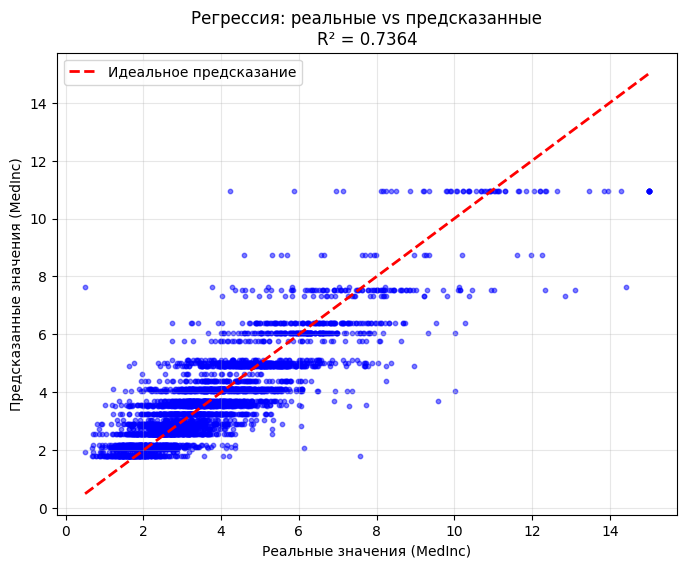

In [8]:
# График: реальные vs предсказанные значения
plt.figure(figsize=(8, 6))
plt.scatter(y_test, y_pred, alpha=0.5, s=10, c='blue')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 
         'r--', lw=2, label='Идеальное предсказание')
plt.xlabel('Реальные значения (MedInc)')
plt.ylabel('Предсказанные значения (MedInc)')
plt.title(f'Регрессия: реальные vs предсказанные\nR² = {r2:.4f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

In [9]:
print("ЗАДАЧА 2: КЛАССИФИКАЦИЯ")
median_value = df['MedHouseVal'].median()
df['is_expensive'] = (df['MedHouseVal'] > median_value).astype(int)

print(f"Медианная стоимость дома: {median_value:.4f}")
print(f"\nРаспределение классов:")
print(f"Класс 1 (дорогие дома): {df['is_expensive'].sum()} объектов")
print(f"Класс 0 (дешевые дома): {len(df) - df['is_expensive'].sum()} объектов")

ЗАДАЧА 2: КЛАССИФИКАЦИЯ
Медианная стоимость дома: 1.7970

Распределение классов:
Класс 1 (дорогие дома): 10317 объектов
Класс 0 (дешевые дома): 10323 объектов


In [10]:
X_clf = df.drop(['MedHouseVal', 'is_expensive'], axis=1)
y_clf = df['is_expensive']

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)
print(f"Обучающая выборка: {X_train_c.shape[0]} объектов")
print(f"Тестовая выборка: {X_test_c.shape[0]} объектов")

Обучающая выборка: 16512 объектов
Тестовая выборка: 4128 объектов


In [11]:
model_clf = DecisionTreeClassifier(max_depth=5, random_state=42)
model_clf.fit(X_train_c, y_train_c)

y_proba = model_clf.predict_proba(X_test_c)[:, 1]
# Считаем AUC-ROC (площадь под ROC-кривой)
auc = roc_auc_score(y_test_c, y_proba)
print(f"\nПлощадь под ROC-кривой (AUC): {auc:.4f}")


Площадь под ROC-кривой (AUC): 0.8768


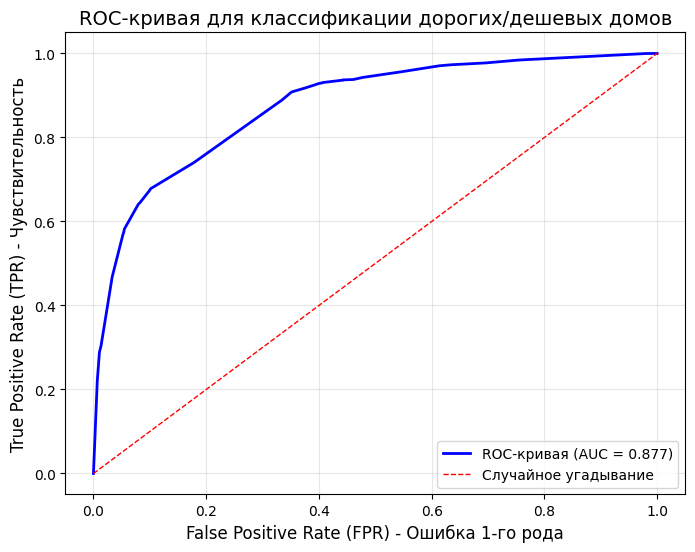

- AUC = 0.877


In [12]:
# Рассчитываем TPR и FPR для разных порогов
fpr, tpr, thresholds = roc_curve(y_test_c, y_proba)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, 'b-', linewidth=2, label=f'ROC-кривая (AUC = {auc:.3f})')
plt.plot([0, 1], [0, 1], 'r--', linewidth=1, label='Случайное угадывание')
plt.xlabel('False Positive Rate (FPR) - Ошибка 1-го рода', fontsize=12)
plt.ylabel('True Positive Rate (TPR) - Чувствительность', fontsize=12)
plt.title('ROC-кривая для классификации дорогих/дешевых домов', fontsize=14)
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

print(f"- AUC = {auc:.3f}")

In [13]:
from sklearn.metrics import accuracy_score

y_pred_c = model_clf.predict(X_test_c)
accuracy = accuracy_score(y_test_c, y_pred_c)

print(f"Точность классификации (Accuracy): {accuracy:.4f}")
print("(Доля правильно предсказанных объектов)")

Точность классификации (Accuracy): 0.7875
(Доля правильно предсказанных объектов)
